First, we need to mount Google Drive to access your files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q optuna xgboost mlflow imbalanced-learn shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURACIÓN DE MLOPS (DAGSHUB) ---
os.environ["MLFLOW_TRACKING_URI"] = "https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = "GaboGolCs"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "42f7e673b8edabb1bb9a4936359bb2fbe533a53c"

# --- 2. CARGA DEL DATASET DESDE UNIDADES COMPARTIDAS ---
# Ruta exacta apuntando al Shareddrive del equipo
ruta_dataset = '/content/drive/Shareddrives/DATA_GPI/Grupo2_Desarrollo/Hito4/Actividad3/dataset_elite_biovid.csv.xls'

df = pd.read_csv(ruta_dataset)
print(f"\n[+] Dataset cargado correctamente desde Unidades Compartidas.")

# Exclusión de las columnas de metadatos para evitar data leakage
cols_metadatos = ['subject_name', 'sample_name', 'class_id', 'class_name', 'error_procesamiento', 'timestamp', 'video_name']
feature_cols = [c for c in df.columns if c not in cols_metadatos]

X = df[feature_cols]
y = df['class_id']
grupos = df['subject_name']

# --- 3. PARTICIÓN POR SUJETOS (GroupKFold) Y BALANCEO HÍBRIDO (SMOTETomek) ---
gkf = GroupKFold(n_splits=5)

print("\n--- Iniciando Ciclos de Partición y Balanceo (Tarea 1) ---")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=grupos)):
    # Aislamiento por sujeto
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # SMOTETomek se aplica ÚNICAMENTE a los conjuntos de entrenamiento
    smt = SMOTETomek(random_state=42)
    X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

    print(f"\n[+] Fold {fold + 1} Procesado:")
    print(f"    - Set de Validación Real (Intacto): {X_val.shape[0]} muestras")
    print(f"    - Set de Entrenamiento Original:    {X_train.shape[0]} muestras")
    print(f"    - Set de Entrenamiento Balanceado:  {X_train_res.shape[0]} muestras")

print(" Los datos están listos para el entrenamiento.")


[+] Dataset cargado correctamente desde Unidades Compartidas.

--- Iniciando Ciclos de Partición y Balanceo (Tarea 1) ---

[+] Fold 1 Procesado:
    - Set de Validación Real (Intacto): 1800 muestras
    - Set de Entrenamiento Original:    6800 muestras
    - Set de Entrenamiento Balanceado:  6744 muestras

[+] Fold 2 Procesado:
    - Set de Validación Real (Intacto): 1700 muestras
    - Set de Entrenamiento Original:    6900 muestras
    - Set de Entrenamiento Balanceado:  6848 muestras

[+] Fold 3 Procesado:
    - Set de Validación Real (Intacto): 1700 muestras
    - Set de Entrenamiento Original:    6900 muestras
    - Set de Entrenamiento Balanceado:  6828 muestras

[+] Fold 4 Procesado:
    - Set de Validación Real (Intacto): 1700 muestras
    - Set de Entrenamiento Original:    6900 muestras
    - Set de Entrenamiento Balanceado:  6824 muestras

[+] Fold 5 Procesado:
    - Set de Validación Real (Intacto): 1700 muestras
    - Set de Entrenamiento Original:    6900 muestras
    - 

TAREA 2 Optimización de Hiperparámetros (Optuna) + MLOps (MLflow)

In [ ]:
# TAREA 2: Optimización de Hiperparámetros (Optuna) + MLOps (MLflow)
import numpy as np, pandas as pd
import xgboost as xgb, optuna, mlflow, mlflow.xgboost
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from imblearn.combine import SMOTETomek
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Features SIN identificadores (evita data leakage: subject_id / sample_id) ---
cols_metadatos = ['subject_id', 'subject_name', 'class_id', 'class_name', 'sample_id',
                  'sample_name', 'error_procesamiento', 'timestamp', 'video_name']
feature_cols = [c for c in df.columns if c not in cols_metadatos]
X = df[feature_cols]
y = df['class_id']
grupos = df['subject_name']
print(f"[*] Optimizando con {len(feature_cols)} features del Equipo de Élite.")

N_SPLITS  = 5
N_TRIALS  = 20   # súbelo para una búsqueda más exhaustiva
NUM_CLASS = int(np.unique(y).size)

# --- Evaluación por validación cruzada de un conjunto de hiperparámetros ---
def evaluar_cv(params, n_splits=N_SPLITS):
    gkf = GroupKFold(n_splits=n_splits)
    f1s = []
    for tr_idx, va_idx in gkf.split(X, y, groups=grupos):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]   # validación 100% real (intacta)
        # SMOTETomek SOLO en entrenamiento
        X_tr_res, y_tr_res = SMOTETomek(random_state=42).fit_resample(X_tr, y_tr)
        modelo = xgb.XGBClassifier(**params)
        modelo.fit(X_tr_res, y_tr_res)
        f1s.append(f1_score(y_va, modelo.predict(X_va), average='macro'))
    return float(np.mean(f1s)), float(np.std(f1s))

# --- Función objetivo de Optuna: define el ESPACIO DE BÚSQUEDA y maximiza F1-Macro ---
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': NUM_CLASS,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',          # añade device='cuda' si activas GPU
        'n_estimators':     trial.suggest_int('n_estimators', 200, 600, step=50),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample':        trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'random_state': 42,
    }
    f1_mean, f1_std = evaluar_cv(params)
    # Registrar AUTOMÁTICAMENTE el trial en MLflow (run anidado)
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_params(trial.params)
        mlflow.log_metric("f1_macro_mean", f1_mean)
        mlflow.log_metric("f1_macro_std",  f1_std)
    return f1_mean

# --- Ejecutar el estudio dentro de un run padre de MLflow ---
mlflow.set_experiment("XGBoost_Cuerpo_Elite")
with mlflow.start_run(run_name="Optuna_Tuning_Tarea2"):
    study = optuna.create_study(direction='maximize', study_name='xgb_elite_optuna')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print(f"\n[+] Mejor F1-Macro: {study.best_value:.4f}")
    print("[+] Mejores hiperparámetros:")
    for k, v in study.best_params.items():
        print(f"    {k}: {v}")

    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_f1_macro", study.best_value)

    # --- Guardar el "MEJOR MODELO" entrenado con todo el dataset ---
    best_params = {**study.best_params, 'objective': 'multi:softprob',
                   'num_class': NUM_CLASS, 'tree_method': 'hist', 'random_state': 42}
    X_res, y_res = SMOTETomek(random_state=42).fit_resample(X, y)
    mejor_modelo = xgb.XGBClassifier(**best_params)
    mejor_modelo.fit(X_res, y_res)
    mlflow.xgboost.log_model(mejor_modelo, "mejor_modelo_optuna")
    print("\n[+] Mejor modelo registrado en MLflow.")

# Dejar disponibles los mejores parámetros para la Tarea 3 (entrenamiento final)
mejores_params = best_params
print("\n>> 'mejores_params' listo para la Tarea 3 (Integrante 3).")

[*] Optimizando con 10 features del Equipo de Élite.


  0%|          | 0/20 [00:00<?, ?it/s]

🏃 View run trial_0 at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4/runs/f7446edf558b4027ac71cb94d117cce2
🧪 View experiment at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4
🏃 View run trial_1 at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4/runs/7d92afeb2af04ca1aafc89baf56a2bee
🧪 View experiment at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4
🏃 View run trial_2 at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4/runs/0d419fc02ff54db7a2fbdabe26e21765
🧪 View experiment at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4
🏃 View run trial_3 at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4/runs/fa3ccac6bc20422f95adcf3056826526
🧪 View experiment at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4
🏃 View run trial_4 at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4/runs/5

2026/07/01 00:14:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



[+] Mejor modelo registrado en MLflow.
🏃 View run Optuna_Tuning_Tarea2 at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4/runs/1c6b6e4235004e4eab764c1ad5551cf4
🧪 View experiment at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/4

>> 'mejores_params' listo para la Tarea 3 (Integrante 3).


TAREA 3: Entrenamiento final, evaluación multiclase y exportación JSON

Sujetos entrenamiento: 68 | validación: 18
Entrenamiento balanceado: (4860, 10) | validación intacta: (1800, 10)
--- Métricas de validación ---
accuracy        : 0.3522
f1_macro        : 0.3443
mcc             : 0.1910
precision_macro : 0.3417
recall_macro    : 0.3522

--- Reporte de clasificación ---

              precision    recall  f1-score   support

         BL1     0.3474    0.2972    0.3204       360
         PA1     0.2740    0.2222    0.2454       360
         PA2     0.2605    0.2417    0.2507       360
         PA3     0.3230    0.3778    0.3483       360
         PA4     0.5034    0.6222    0.5565       360

    accuracy                         0.3522      1800
   macro avg     0.3417    0.3522    0.3443      1800
weighted avg     0.3417    0.3522    0.3443      1800



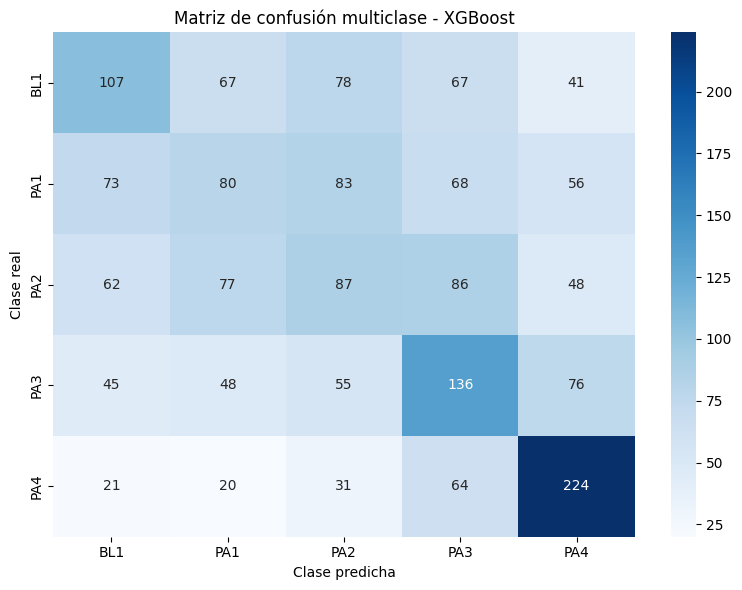

Modelo final exportado correctamente: /content/xgboost_cuerpo.json
Tamaño del archivo: 2167.2 KB


In [ ]:
# 1. Preparación del modelo y partición final por sujetos
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score
)
from sklearn.model_selection import GroupKFold
from imblearn.combine import SMOTETomek

# Permite ejecutar la Tarea 3 aunque no se repita el estudio de Optuna.
params_optuna = (study.best_params if 'study' in globals() else {
    'n_estimators': 350,
    'max_depth': 3,
    'learning_rate': 0.03264234017341051,
    'min_child_weight': 5,
    'subsample': 0.8220441239684355,
    'colsample_bytree': 0.8641962378834953,
    'gamma': 0.7114477633160532,
})
params_finales = {
    **params_optuna,
    'objective': 'multi:softprob',
    'num_class': int(y.nunique()),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
}

# Primer fold reproducible: ningún sujeto aparece simultáneamente en ambos conjuntos.
gkf_final = GroupKFold(n_splits=5)
idx_train, idx_val = next(gkf_final.split(X, y, groups=grupos))
X_train_final, y_train_final = X.iloc[idx_train], y.iloc[idx_train]
X_val_final, y_val_final = X.iloc[idx_val], y.iloc[idx_val]
grupos_train = set(grupos.iloc[idx_train])
grupos_val = set(grupos.iloc[idx_val])
assert grupos_train.isdisjoint(grupos_val), 'Data leakage: hay sujetos repetidos.'

X_train_res_final, y_train_res_final = SMOTETomek(random_state=42).fit_resample(
    X_train_final, y_train_final
)
print(f'Sujetos entrenamiento: {len(grupos_train)} | validación: {len(grupos_val)}')
print(f'Entrenamiento balanceado: {X_train_res_final.shape} | validación intacta: {X_val_final.shape}')

# 2. Entrenamiento y evaluación multiclase
modelo_evaluacion = xgb.XGBClassifier(**params_finales)
modelo_evaluacion.fit(X_train_res_final, y_train_res_final)
y_pred = modelo_evaluacion.predict(X_val_final)

metricas = {
    'accuracy': accuracy_score(y_val_final, y_pred),
    'f1_macro': f1_score(y_val_final, y_pred, average='macro', zero_division=0),
    'mcc': matthews_corrcoef(y_val_final, y_pred),
    'precision_macro': precision_score(y_val_final, y_pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_val_final, y_pred, average='macro', zero_division=0),
}
print('--- Métricas de validación ---')
for nombre, valor in metricas.items():
    print(f'{nombre:16s}: {valor:.4f}')

# Nombres de clase ordenados según class_id.
mapa_clases = (df[['class_id', 'class_name']].drop_duplicates()
               .sort_values('class_id').set_index('class_id')['class_name'].to_dict())
etiquetas = sorted(y.unique())
nombres_clases = [mapa_clases.get(i, str(i)) for i in etiquetas]
reporte = classification_report(
    y_val_final, y_pred, labels=etiquetas, target_names=nombres_clases,
    zero_division=0, digits=4
)
print('\n--- Reporte de clasificación ---\n')
print(reporte)

cm = confusion_matrix(y_val_final, y_pred, labels=etiquetas)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de confusión multiclase - XGBoost')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.tight_layout()
plt.savefig('matriz_confusion_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Reentrenamiento definitivo y exportación física en formato plano JSON
X_res_completo, y_res_completo = SMOTETomek(random_state=42).fit_resample(X, y)
modelo_final = xgb.XGBClassifier(**params_finales)
modelo_final.fit(X_res_completo, y_res_completo)

ruta_modelo = Path('xgboost_cuerpo.json')
modelo_final.save_model(ruta_modelo)
assert ruta_modelo.exists() and ruta_modelo.stat().st_size > 0
with ruta_modelo.open('r', encoding='utf-8') as archivo:
    json.load(archivo)  # valida que el artefacto sea JSON legítimo

print(f'Modelo final exportado correctamente: {ruta_modelo.resolve()}')
print(f'Tamaño del archivo: {ruta_modelo.stat().st_size / 1024:.1f} KB')


Tarea 4: Explicabilidad Global/Local con SHAP (IA Explicable):

[*] Inicializando TreeExplainer...
[*] Calculando SHAP values sobre X real (sin SMOTE)...
    Shape: (8600, 10, 5)
    ✓ 8600 muestras × 10 features × 5 clases

=== RANKING SHAP GLOBAL ===


,Biomarcador,SHAP_Importancia_Global
0,gsr_slope_late,0.248468
1,emg_corrugator_max,0.231676
2,gsr_min_max_diff,0.120615
3,emg_zygomaticus_auc,0.105195
4,emg_corrugator_mean,0.063401
5,ecg_apen,0.058124
6,gsr_apen,0.051799
7,emg_trapezius_max,0.049702
8,emg_trapezius_auc,0.049372
9,ecg_bpm,0.043608


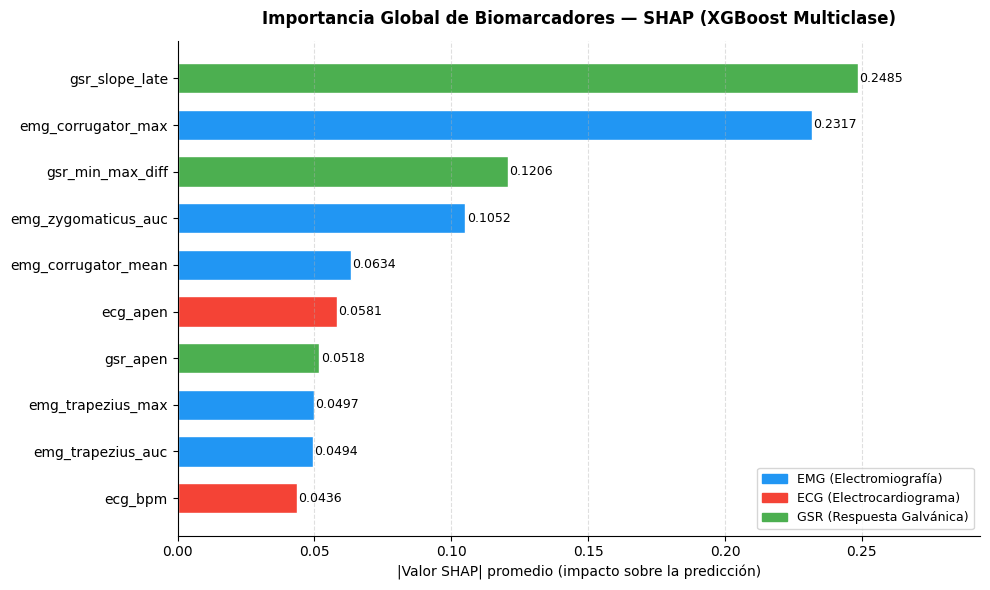

✓ Gráfica exportada: shap_importancia_global.png


In [ ]:
# ============================================================
# TAREA 4: EXPLICABILIDAD GLOBAL CON SHAP (IA EXPLICABLE)
# ============================================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Paso 1: TreeExplainer sobre modelo_final ---
# SHAP se calcula sobre X real (sin SMOTE) para no contaminar
# las explicaciones con muestras artificiales
print("[*] Inicializando TreeExplainer...")
explainer = shap.TreeExplainer(modelo_final)

# --- Paso 2: Calcular SHAP values ---
print("[*] Calculando SHAP values sobre X real (sin SMOTE)...")
shap_values = explainer.shap_values(X)

# Validación de estructura 3D: (n_samples, n_features, n_classes)
shap_array = np.array(shap_values)
print(f"    Shape: {shap_array.shape}")
assert shap_array.ndim == 3
print(f"    ✓ {shap_array.shape[0]} muestras × {shap_array.shape[1]} features × {shap_array.shape[2]} clases")

# --- Paso 3: Importancia global por biomarcador ---
# |SHAP|.mean(axis=0) → (features, clases)
# .mean(axis=1)       → (features,)
importancia_global = np.abs(shap_array).mean(axis=0).mean(axis=1)

df_shap = pd.DataFrame({
    'Biomarcador': feature_cols,
    'SHAP_Importancia_Global': importancia_global
}).sort_values('SHAP_Importancia_Global', ascending=False).reset_index(drop=True)

print("\n=== RANKING SHAP GLOBAL ===")
display(df_shap)

# --- Paso 4: Gráfica de importancia SHAP ---
def color_señal(nombre):
    n = nombre.lower()
    if n.startswith('emg'): return '#2196F3'
    if n.startswith('ecg'): return '#F44336'
    if n.startswith('gsr'): return '#4CAF50'
    return '#9E9E9E'

df_plot  = df_shap.sort_values('SHAP_Importancia_Global', ascending=True)
colores  = [color_señal(b) for b in df_plot['Biomarcador']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['Biomarcador'], df_plot['SHAP_Importancia_Global'],
               color=colores, edgecolor='white', height=0.65)

for bar, val in zip(bars, df_plot['SHAP_Importancia_Global']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

leyenda = [Patch(color='#2196F3', label='EMG (Electromiografía)'),
           Patch(color='#F44336', label='ECG (Electrocardiograma)'),
           Patch(color='#4CAF50', label='GSR (Respuesta Galvánica)')]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

ax.set_xlabel('|Valor SHAP| promedio (impacto sobre la predicción)', fontsize=10)
ax.set_title('Importancia Global de Biomarcadores — SHAP (XGBoost Multiclase)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, df_plot['SHAP_Importancia_Global'].max() * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('shap_importancia_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfica exportada: shap_importancia_global.png")